Loading MNIST...
MNISTNet(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)
Total parameters: 109,386
Epoch  1 | Loss: 0.4054 | Train: 0.8791 | Test: 0.9465
Epoch  2 | Loss: 0.1769 | Train: 0.9468 | Test: 0.9589
Epoch  3 | Loss: 0.1328 | Train: 0.9610 | Test: 0.9665
Epoch  4 | Loss: 0.1082 | Train: 0.9672 | Test: 0.9694
Epoch  5 | Loss: 0.0946 | Train: 0.9707 | Test: 0.9733
Epoch  6 | Loss: 0.0826 | Train: 0.9744 | Test: 0.9739
Epoch  7 | Loss: 0.0744 | Train: 0.9765 | Test: 0.9743
Epoch  8 | Loss: 0.0701 | Train: 0.9779 | Test: 0.9736
Epoch  9 | Loss: 0.0648 | Train: 0.9796 | Test: 0.9755
Epoch 10 | Loss: 0.0585 | Train: 0.9812 | Test: 0.9756
Epoch 11 | Loss: 0.0574 | Train: 0.9810 | Test: 0.9751
Epoch 12 | Loss: 0.0520 | Train: 0.9829 | Test: 0.9743
Epoch 13 | Loss: 0.0493 | Train: 0.9837 | Test: 0.9776
Epoc

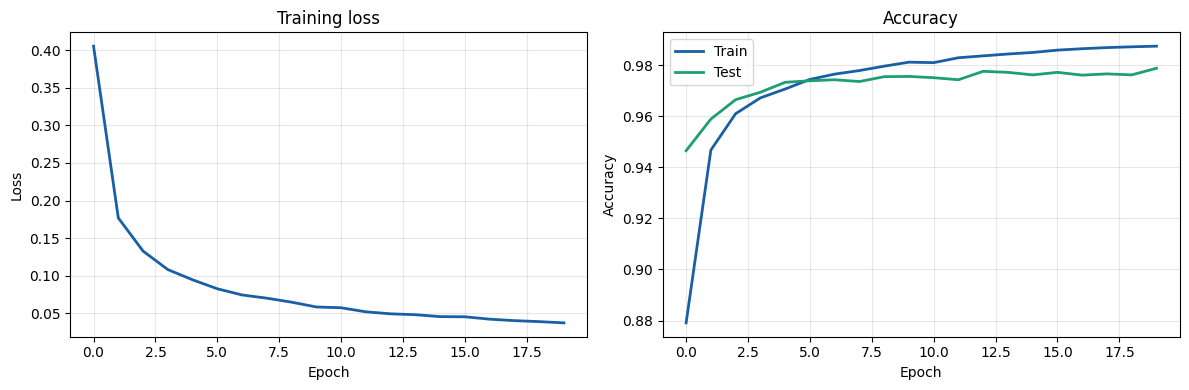


Final test accuracy: 0.9788


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

#  Loading data 
print("Loading MNIST...")
mnist   = fetch_openml('mnist_784', version=1, as_frame=False)
X       = mnist.data.astype(np.float32) / 255.0
y       = mnist.target.astype(np.int64)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=10000, random_state=42
)

#  Converting numpy to PyTorch tensors
X_tr_t = torch.from_numpy(X_tr)
y_tr_t = torch.from_numpy(y_tr)
X_te_t = torch.from_numpy(X_te)
y_te_t = torch.from_numpy(y_te)

# DataLoader handles batching and shuffling automatically
train_ds     = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)


#  Define network
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.dropout = nn.Dropout(0.2)  # randomly zero 20% of neurons prevents overfitting

    def forward(self, x):
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x


model     = MNISTNet()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")


#  Training loop
def train_epoch(model, loader, criterion, optimizer):
    model.train()   # training mode — dropout active
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in loader:
        
        y_pred = model(X_batch)              # 1. forward
        loss   = criterion(y_pred, y_batch)  # 2. loss
        optimizer.zero_grad()                # 3. clear gradients
        loss.backward()                      # 4. backward
        optimizer.step()                     # 5. update

        total_loss += loss.item()
        correct    += (y_pred.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / len(loader), correct / total


def evaluate(model, X, y):
    model.eval()   
    with torch.no_grad():   
        preds = model(X).argmax(1)
    return (preds == y).float().mean().item()


#  Run training
losses, train_accs, test_accs = [], [], []

for epoch in range(20):
    loss, train_acc = train_epoch(model, train_loader,
                                   criterion, optimizer)
    test_acc = evaluate(model, X_te_t, y_te_t)

    losses.append(loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1:2d} | Loss: {loss:.4f} "
          f"| Train: {train_acc:.4f} | Test: {test_acc:.4f}")


#  Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses, color='#185FA5', linewidth=2)
ax1.set_title('Training loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

ax2.plot(train_accs, label='Train', color='#185FA5', linewidth=2)
ax2.plot(test_accs,  label='Test',  color='#1D9E75', linewidth=2)
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal test accuracy: {test_accs[-1]:.4f}")

In [3]:
# Save
torch.save(model.state_dict(), 'mnist_model.pth')
print("Model saved!")

# Load later
model_loaded = MNISTNet()
model_loaded.load_state_dict(torch.load('mnist_model.pth'))
model_loaded.eval()

# Predict on a single image
single_image = X_te_t[0].unsqueeze(0)   # add batch dim → (1, 784)
with torch.no_grad():
    output = model_loaded(single_image)
    pred   = output.argmax().item()
print(f"Predicted: {pred}, True: {y_te[0]}")

Model saved!
Predicted: 8, True: 8


In [8]:
class MNISTNetV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Wider network — no BatchNorm
        self.fc1     = nn.Linear(784, 512)
        self.fc2     = nn.Linear(512, 256)
        self.fc3     = nn.Linear(256, 128)
        self.fc4     = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x


model_v2  = MNISTNetV2()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_v2.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)

print(model_v2)
print(f"Parameters: {sum(p.numel() for p in model_v2.parameters()):,}")



def evaluate(model, X, y):
    model.eval()
    correct = 0
    with torch.no_grad():
        for start in range(0, len(X), 256):
            X_b = X[start:start+256]
            y_b = y[start:start+256]
            correct += (model(X_b).argmax(1) == y_b).sum().item()
    return correct / len(y)


# Training
for epoch in range(30):
    loss, train_acc = train_epoch(model_v2, train_loader,
                                   criterion, optimizer)
    test_acc   = evaluate(model_v2, X_te_t, y_te_t)
    scheduler.step(test_acc)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1:2d} | Loss: {loss:.4f} "
          f"| Train: {train_acc:.4f} | Test: {test_acc:.4f} "
          f"| LR: {current_lr:.6f}")

print(f"\nBest: {max([evaluate(model_v2, X_te_t, y_te_t)]):.4f}")

MNISTNetV2(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
Parameters: 567,434
Epoch  1 | Loss: 0.2949 | Train: 0.9103 | Test: 0.9604 | LR: 0.001000
Epoch  2 | Loss: 0.1252 | Train: 0.9626 | Test: 0.9682 | LR: 0.001000
Epoch  3 | Loss: 0.0961 | Train: 0.9700 | Test: 0.9738 | LR: 0.001000
Epoch  4 | Loss: 0.0797 | Train: 0.9758 | Test: 0.9752 | LR: 0.001000
Epoch  5 | Loss: 0.0700 | Train: 0.9782 | Test: 0.9759 | LR: 0.001000
Epoch  6 | Loss: 0.0636 | Train: 0.9808 | Test: 0.9789 | LR: 0.001000
Epoch  7 | Loss: 0.0547 | Train: 0.9831 | Test: 0.9770 | LR: 0.001000
Epoch  8 | Loss: 0.0508 | Train: 0.9841 | Test: 0.9783 | LR: 0.001000
Epoch  9 | Loss: 0.0474 | Train: 0.9857 | Test: 0.9794 | LR: 0.001000
Epoch 10 | Loss: 0.0429 | Train: 0.9865 | Test